# Bag of Words & Logistic Regression Classifier Baseline

In [28]:
import csv
import random

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [29]:
languages = ['af', 'de', 'en', 'es', 'fr', 'id', 'it', 'nl', 'pt', 'sv', 'tl', 'tr']

In [30]:
# Load the train, test, validation data
train_dataset = []
test_dataset = []
validation_dataset = []

train_path = f"dataset/train.csv"
with open(train_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        train_dataset.append(row)

    random.shuffle(train_dataset)
    train_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in train_dataset]
    
test_path = f"dataset/test.csv"
with open(test_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_dataset.append(row)

    random.shuffle(test_dataset)
    test_dataset = [{'id': item['id'], 'text': item['text']} for item in test_dataset]

validation_path = f"dataset/validation.csv"
with open(validation_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        validation_dataset.append(row)

    random.shuffle(validation_dataset)
    validation_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in validation_dataset]

## Visualizing the data

In [31]:
# Visualize the training dataset
print("Sample training data:")
train_df = pd.DataFrame(train_dataset)
train_df.head(10)

Sample training data:


,id,text,lang
0,57343,qué necesito completar primero de la lista,es
1,52881,vertel me de snelheid om naar de zon te gaan,nl
2,8266,j'ai besoin d'avoir une meilleure concentratio...,fr
3,24317,hesap makinesini aç,tr
4,35768,aydın dan kuşadası na bir tren bileti ayırt,tr
5,48840,buche ein zug ticket mit einem schlafplatz nac...,de
6,29241,waktunya olahraga,id
7,29832,maak alsjeblieft een lekkere koffie voor mij,nl
8,21452,descrição do iphone sete,pt
9,15813,fammi vedere che email ho ricevuto,it


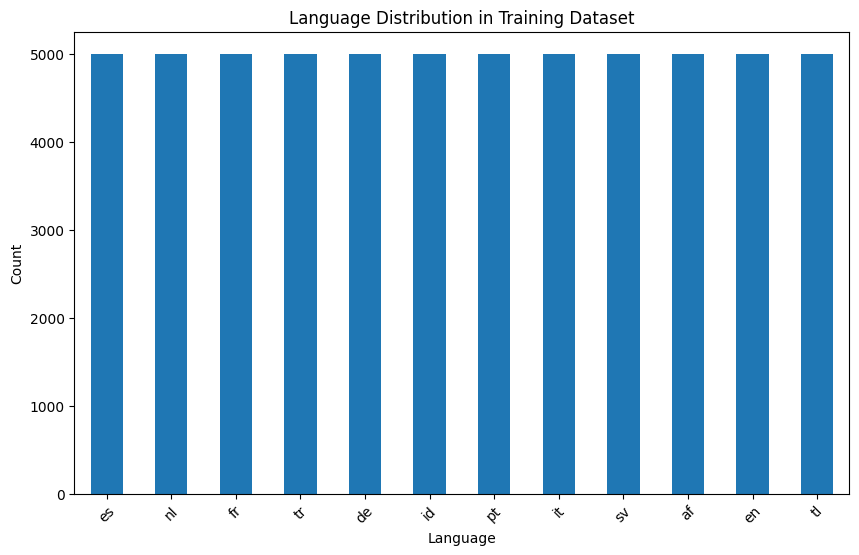

In [32]:
plt.figure(figsize=(10, 6))
train_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Training Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [33]:
# Visualize the test dataset
print("Sample test data:")
test_df = pd.DataFrame(test_dataset)
test_df.head(10)

Sample test data:


,id,text
0,1901,olly wie ist die wettervorhersage von heute
1,29152,pagpupulong bukas
2,14624,olly dis moi mes alarmes
3,8009,il tasso di cambio del dollaro è aumentato
4,12496,maak een nieuw schema voor de vergadering van ...
5,33701,itigil
6,11005,an welchem neuen film arbeitet max riemelt
7,10357,stel asseblief 'n kennisgewing vir die drie-en...
8,19957,ada apa hari ini
9,13222,que tengo que hacer esta semana


In [34]:
# Visualize the validation dataset
print("Sample validation data:")
validation_df = pd.DataFrame(validation_dataset)
validation_df.head(10)

Sample validation data:


,id,text,lang
0,17757,pon en bucle esta canción,es
1,7324,if it's eight p. m. on the east coast what tim...,en
2,15145,o que está acontecer no bairro,pt
3,5690,beställ vårrullar att ta med,sv
4,16826,quantas polegadas fazem um pé,pt
5,14111,was ist drei mal sieben,de
6,19044,kan du skicka en tweet till podcaster att dera...,sv
7,2715,lembrar-me da reunião na terça-feira,pt
8,4619,latest events,en
9,13824,please search for this word,en


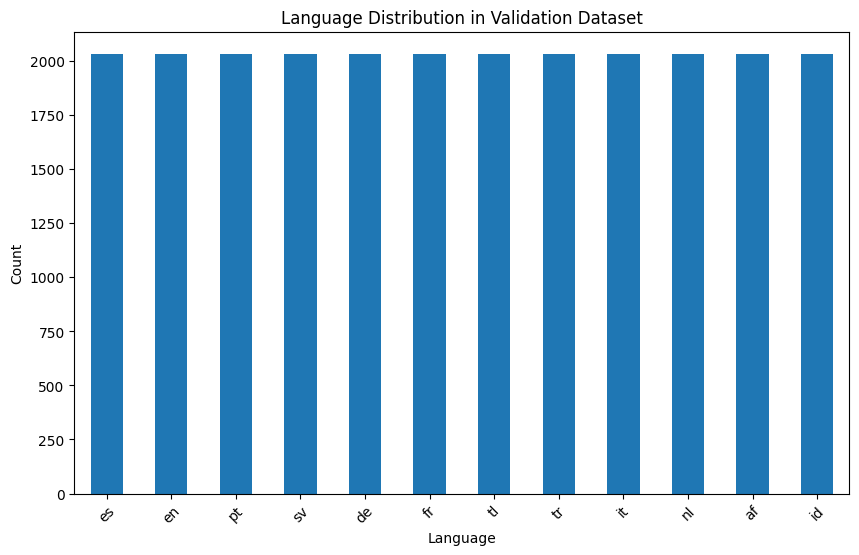

In [35]:
plt.figure(figsize=(10, 6))
validation_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Validation Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Model Training

In [36]:
# Split the data into features and labels
X_train = [item['text'] for item in train_dataset]
y_train = [item['lang'] for item in train_dataset]

X_test = [item['text'] for item in test_dataset]

X_val = [item['text'] for item in validation_dataset]
y_val = [item['lang'] for item in validation_dataset]

In [37]:
# Create a BoW 
bow_vectorizer = CountVectorizer(lowercase=True, strip_accents=None)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
X_val_bow = bow_vectorizer.transform(X_val)

In [38]:
classifier = LogisticRegression()
classifier.fit(X_train_bow, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Evaluation

In [39]:
y_pred = classifier.predict(X_val_bow)

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='macro')

print(f"Accuracy: {accuracy*100:.4f}%")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 97.0692%
F1 Score: 0.9711

Classification Report:
              precision    recall  f1-score   support

          af       0.97      0.95      0.96      2033
          de       0.99      0.97      0.98      2033
          en       0.98      0.97      0.98      2033
          es       0.98      0.95      0.97      2033
          fr       0.99      0.97      0.98      2033
          id       0.98      0.99      0.99      2033
          it       0.99      0.97      0.98      2033
          nl       0.97      0.95      0.96      2033
          pt       0.96      0.98      0.97      2033
          sv       0.99      0.97      0.98      2033
          tl       1.00      0.98      0.99      2033
          tr       0.85      0.99      0.92      2033

    accuracy                           0.97     24396
   macro avg       0.97      0.97      0.97     24396
weighted avg       0.97      0.97      0.97     24396



In [40]:
# Run your prediction on the test set and save the results to a CSV file
y_test_pred = classifier.predict(X_test_bow)

output_df = pd.DataFrame({'id': [item['id'] for item in test_dataset], 'lang': y_test_pred})
output_df.to_csv('prediction_results.csv', index=False)